This is MNIST Digit Classification with CNNs. The dataset contains multiple images with numbers that made from a grid of pixels. A convolutional Neural Network would be trained, which would be of multiple layers and an independent test set would be tested to test the model's accuracy.

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm.auto import tqdm
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
transform = transforms.ToTensor()

#importing the training data and splitting it into training and validation dataloaders
train_data = datasets.MNIST(
    root = 'data',
    train = True,
    download = True,
    transform = transform,
    target_transform= None
)

test_data = datasets.MNIST(
    root = 'data',
    train = False,
    download = True,
    transform = transform
)

train_size = int(0.8 * len(train_data)) #80% of the training data
val_size = len(train_data) - train_size
train_set, val_set = random_split(train_data, [train_size, val_size])
#train dataloader
train_loader = DataLoader(train_set, batch_size = 32, shuffle = True)
#val dataloader
val_loader = DataLoader(val_set, batch_size = 32, shuffle = False)
#test dataloader
test_loader = DataLoader(test_data, batch_size = 32, shuffle = False)

class_names = train_data.classes
print(f"Class Names: {class_names}")
print(f"Len of train data: {len(train_data)}\tTest data; {len(test_data)}")
print(f"Training Batches: {len(train_loader)}\tValidation Batches: {len(val_loader)}\tTesting batches: {len(test_loader)}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.09MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]

Class Names: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Len of train data: 60000	Test data; 10000
Training Batches: 1500	Validation Batches: 375	Testing batches: 313


torch.Size([32, 1, 28, 28])


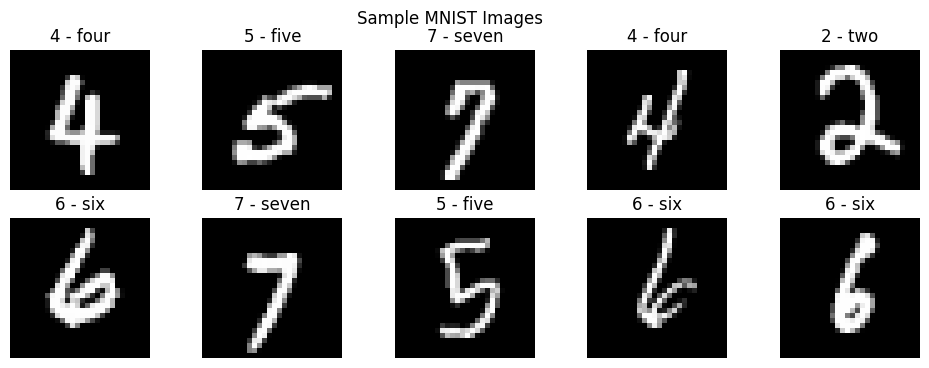

In [ ]:
images, labels = next(iter(train_loader))
print(images.shape) #NCHW

plt.figure(figsize=(12,4))
#0-9
for i in range(10):
  plt.subplot(2,5,i+1)#subplot indices start at 1. so i+1
  plt.imshow(images[i].squeeze(), cmap= 'gray')
  plt.title(class_names[labels[i]])
  plt.axis(False)

plt.suptitle('Sample MNIST Images')
plt.show()

Builidng our base model:
We will be implementing three blocks: two would be convolution blocks and one would be classifier. Conv blocks would undergo data transformation and would be fed as input to the fully connected layer at classifier layer.

In [ ]:
from torch.nn.modules.pooling import MaxPool2d
#building our base model
class MNISTClassifier(nn.Module):
  def __init__(self):
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Conv2d(in_channels = 1, out_channels = 20, kernel_size= 3, padding = 1, stride = 1), #[20, 28, 28] per image in a batch
        nn.ReLU(), #[20, 28, 28]
        nn.Conv2d(in_channels= 20, out_channels = 30, kernel_size= 3, padding = 1, stride = 1), #[30,28,28],
        nn.ReLU(), #[30,28,28],
        nn.MaxPool2d(kernel_size= 2, stride = 2) #(28-2)/2 +1 = 13 +1 = 14 ... [30,14,14]
    )

    self.block_2 = nn.Sequential(
        nn.Conv2d(in_channels = 30, out_channels = 30, kernel_size = 3, padding = 1, stride = 1), #[30,14,14]
        nn.ReLU(), #[30,14,14]
        nn.Conv2d(in_channels= 30, out_channels = 40, kernel_size = 3, padding = 1, stride = 1), #[40,14,14]
        nn.ReLU(), #[40,14,14]
        nn.MaxPool2d(kernel_size=2, stride = 2) #[40, 7, 7]-> Now at this point, we will have about 40 different feature maps for one original image
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = 40 * 7 * 7, out_features = 196), #we will be reducing the number of input by 10 times
        nn.ReLU(),
        nn.Linear(in_features = 196, out_features = len(class_names))
    )

  def forward(self, x):
    return self.classifier(self.block_2(self.block_1(x)))

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MNISTClassifier().to(device)

#setting up the loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params = model.parameters(),
    lr = 0.01
)

next(iter(model.parameters())).device

device(type='cuda', index=0)

In [ ]:
#writing a training and validation loop
torch.manual_seed(42)
epochs = 10

train_losses, val_losses, val_acc = [],[],[]
for epoch in range(epochs):
  print(f"Epoch: {epoch+1}")
  train_loss = 0
  model.train() #this will put the model in training mode
  train_bar = tqdm(train_loader, desc = "Training")

  #now the training loop-> we will be processing 1500 batches of 32 images in one training epoch
  #per iteration would have a batch of 32 images and this for loop would be repeated a total of 1500 images.
  #and in each loop, these 32 images would be fed into the network, loss would be computed and weights would be updated

  for image, label in train_bar:
    image, label = image.to(device), label.to(device)
    #this is the forward pass
    y_logit = model(image)
    loss = loss_fn(y_logit, label)
    train_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  #putting the model into inference mode
  model.eval()
  val_loss, correct, total = 0,0,0
  val_bar = tqdm(val_loader, desc = "Validation")
  with torch.inference_mode():
    for image, label in val_bar:
      image, label = image.to(device), label.to(device)
      y_logit = model(image)
      y_pred = y_logit.argmax(dim = 1)
      loss = loss_fn(y_logit, label)
      val_loss += loss.item()
      correct += (y_pred == label).sum().item()
      total += label.size(0)

  train_losses.append(train_loss / len(train_loader))
  val_losses.append(val_loss/ len(val_loader))
  val_acc.append(correct/total * 100)

  print(f"Epoch {epoch+1}/10 | Train Loss: {train_losses[-1]:.4f} | Test Loss: {val_losses[-1]:.4f} | Accuracy: {val_acc[-1]:.2f}%")

Epoch: 1


Training:   0%|          | 0/1500 [00:00<?, ?it/s]

Validation:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 1.9721 | Test Loss: 0.4072 | Accuracy: 87.54%
Epoch: 2


Training:   0%|          | 0/1500 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 0.0294 | Test Loss: 0.0616 | Accuracy: 98.26%
Epoch: 10


Training:   0%|          | 0/1500 [00:00<?, ?it/s]

Validation:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.0262 | Test Loss: 0.0497 | Accuracy: 98.55%


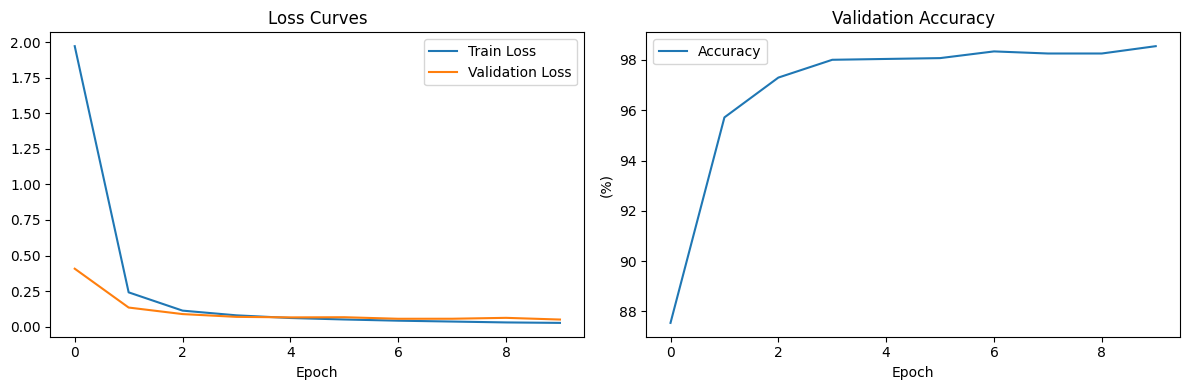

In [ ]:
#plotting our loss curves and accuracy curves
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,4))
ax1.plot(train_losses, label = 'Train Loss')
ax1.plot(val_losses, label = 'Validation Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(val_acc, label = 'Accuracy')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('(%)')
ax2.legend()


plt.tight_layout()
plt.show()

In [ ]:
#evaluating our trained model on unseen data
model.eval()
all_preds, all_labels = [], []
correct, total = 0,0

with torch.inference_mode():
  for image, label in test_loader:
    image = image.to(device)
    #forward pass
    output = model(image)
    y_pred = output.argmax(dim = 1).cpu()
    correct += (y_pred == label).sum().item()
    total += label.size(0) #n * 32 data, number of batches * batch size
    all_preds.extend(y_pred)
    all_labels.extend(label)

  accuracy = (correct/total) * 100
  print(f"Accuracy: {accuracy}")

Accuracy: 98.82


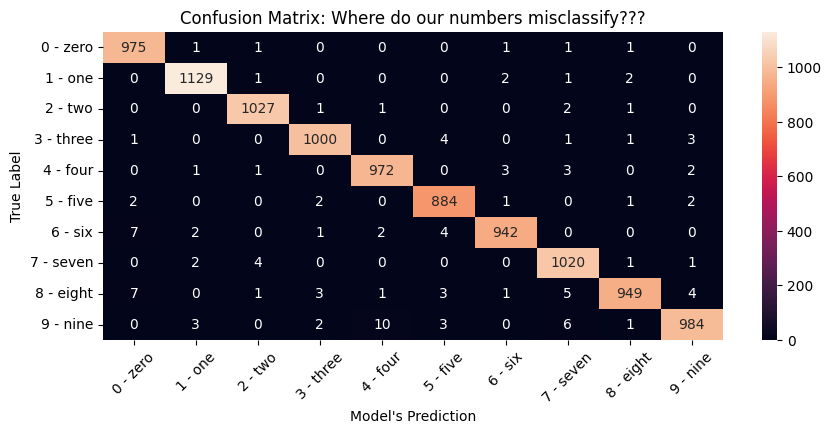

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize = (10,4))
sns.heatmap(cm, annot = True, xticklabels = class_names, yticklabels = class_names, fmt = 'd')
plt.title("Confusion Matrix: Where do our numbers misclassify???")
plt.xlabel('Model\'s Prediction')
plt.ylabel('True Label')
plt.xticks(rotation = 45)
plt.show()

Accuracy is extremely high. This means our model was able to correctly predict most of the numbers. Training Loss tend to go down with the number of epochs, while the validation loss pleatued at around 5th epoch, which is a sign of minor overfitting. CNN's were extremely effective to correctly classify complex visual patterns from the MNIST dataset